## 주가수익률과 기술통계 & IQR 이상치 탐지

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. 삼성전자 주가 데이터 가져오기

In [5]:
from pykrx import stock
import pandas as pd
import matplotlib.pyplot as plt

# 1. 삼성전자 주가 데이터 불러오기
# 삼성전자 종목코드: 005930

df = stock.get_market_ohlcv(
    fromdate="20250101",
    todate="20260730",
    ticker="005930"
)

# 데이터 확인
print(df.head())
print(df.tail())

               시가     고가     저가     종가       거래량       등락률
날짜                                                        
2025-01-02  52700  53600  52300  53400  16630538  0.375940
2025-01-03  52800  55100  52800  54400  19318046  1.872659
2025-01-06  54400  56200  54300  55900  19034284  2.757353
2025-01-07  56800  57300  55400  55400  17030235 -0.894454
2025-01-08  54800  57500  54700  57300  26593553  3.429603
                시가      고가      저가      종가       거래량        등락률
날짜                                                             
2026-07-24  266000  266500  247000  249500  26175580  -7.592593
2026-07-27  257000  258500  246000  254000  23296044   1.803607
2026-07-28  238500  240000  218500  220000  41639623 -13.385827
2026-07-29  226500  234000  189200  208500  65555523  -5.227273
2026-07-30  214000  226000  202000  207000  46694193  -0.719424


### 2.일간수익률 계산

In [6]:
df["수익률"] = df["종가"].pct_change() * 100

# 첫 번째 행의 결측값 제거
df = df.dropna()

print(df[["종가", "수익률"]].head())

               종가       수익률
날짜                         
2025-01-03  54400  1.872659
2025-01-06  55900  2.757353
2025-01-07  55400 -0.894454
2025-01-08  57300  3.429603
2025-01-09  56100 -2.094241


### 3. 기술통계량 확인

In [7]:
print(df["수익률"].describe())

count    382.000000
mean       0.420069
std        3.600584
min      -13.385827
25%       -1.157025
50%        0.236672
75%        2.242407
max       14.408602
Name: 수익률, dtype: float64


In [8]:
#주요 통계량을 따로 출력할 수도 있습니다.
print("평균수익률 :", round(df["수익률"].mean(), 3), "%")
print("중앙값     :", round(df["수익률"].median(), 3), "%")
print("표준편차   :", round(df["수익률"].std(), 3), "%")
print("최솟값     :", round(df["수익률"].min(), 3), "%")
print("최댓값     :", round(df["수익률"].max(), 3), "%")

평균수익률 : 0.42 %
중앙값     : 0.237 %
표준편차   : 3.601 %
최솟값     : -13.386 %
최댓값     : 14.409 %


### 4. IQR 계산

In [9]:
Q1 = df["수익률"].quantile(0.25)
Q3 = df["수익률"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 :", round(Q1, 3), "%")
print("Q3 :", round(Q3, 3), "%")
print("IQR :", round(IQR, 3), "%")
print("이상치 하한 :", round(lower_bound, 3), "%")
print("이상치 상한 :", round(upper_bound, 3), "%")

Q1 : -1.157 %
Q3 : 2.242 %
IQR : 3.399 %
이상치 하한 : -6.256 %
이상치 상한 : 7.342 %


### 5. 이상치 찾기

In [11]:
# IQR 기준을 이용하여 이상치를 탐지합니다.

outliers = df[
    (df["수익률"] < lower_bound) |
    (df["수익률"] > upper_bound)
]

print("전체 거래일 :", len(df))
print("이상치 개수 :", len(outliers))

print(outliers[["종가", "수익률"]])


전체 거래일 : 382
이상치 개수 : 28
                종가        수익률
날짜                           
2026-01-05  138100   7.470817
2026-02-02  150400  -6.292835
2026-02-03  167500  11.369681
2026-03-03  195100  -9.884527
2026-03-04  172200 -11.737570
2026-03-05  191600  11.265970
2026-03-09  173500  -7.810840
2026-03-10  187900   8.299712
2026-03-18  208500   7.529654
2026-03-23  186300  -6.569709
2026-04-01  189600  13.397129
2026-05-06  266000  14.408602
2026-05-15  270500  -8.614865
2026-05-21  299500   8.514493
2026-06-01  349000  10.094637
2026-06-05  329000  -6.401138
2026-06-08  295500 -10.182371
2026-06-09  322000   8.967851
2026-06-12  322500   7.859532
2026-06-23  310000 -12.305516
2026-06-24  340500   9.838710
2026-07-02  286000  -9.062003
2026-07-03  309500   8.216783
2026-07-07  296000  -6.918239
2026-07-13  254500 -10.701754
2026-07-16  255000  -8.765653
2026-07-24  249500  -7.592593
2026-07-28  220000 -13.385827


In [13]:
# 수익률 변동이 큰 날짜부터 확인하기

#절대수익률(상승·하락의 크기)을 기준으로 가장 큰 변동이 발생한 날짜를 확인합니다.

outliers = outliers.copy()

outliers["절대수익률"] = outliers["수익률"].abs()

print(
    outliers[["종가", "수익률", "절대수익률"]]
    .sort_values("절대수익률", ascending=False)
    .head(10)
)


                종가        수익률      절대수익률
날짜                                      
2026-05-06  266000  14.408602  14.408602
2026-04-01  189600  13.397129  13.397129
2026-07-28  220000 -13.385827  13.385827
2026-06-23  310000 -12.305516  12.305516
2026-03-04  172200 -11.737570  11.737570
2026-02-03  167500  11.369681  11.369681
2026-03-05  191600  11.265970  11.265970
2026-07-13  254500 -10.701754  10.701754
2026-06-08  295500 -10.182371  10.182371
2026-06-01  349000  10.094637  10.094637


In [ ]:
### 결과 해석

# 전체 거래일** : 분석 대상이 된 전체 거래일 수
# 이상치 개수** : IQR 기준을 벗어난 거래일 수
# 종가** : 해당 거래일의 종가
# 수익률** : 해당 거래일의 일간 수익률(%)
# 절대수익률** : 상승·하락 방향과 관계없이 변동의 크기를 나타내는 값

# > 금융 데이터에서 IQR 이상치는 단순한 오류가 아니라 **실적 발표, 금리 변화, 정책 발표, 지정학적 이슈 등으로 인해 
# 주가가 크게 변동한 중요한 거래일**일 가능성이 높습니다. 
# 따라서 금융 데이터 분석에서는 이상치를 무조건 제거하기보다 발생 원인을 함께 분석하는 것이 중요합니다.


### 6. Boxplot으로 IQR 이상치 확인(시각화-전처리 활용)

In [ ]:
# Boxplot(상자그림)은 데이터의 중앙값, 사분위수(IQR), 이상치를 한 번에 확인할 수 있는 대표적인 시각화 방법입니다.

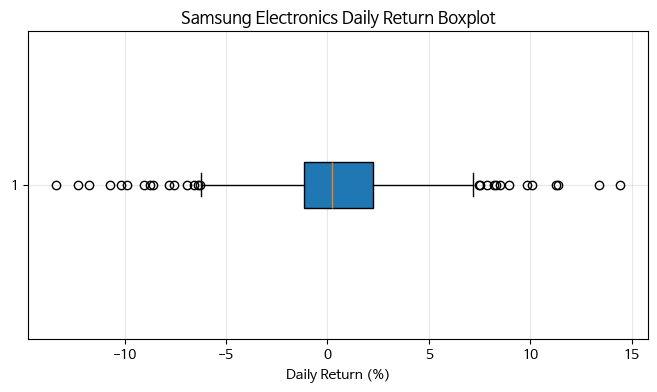

In [14]:
plt.figure(figsize=(8,4))

plt.boxplot(df["수익률"],
            vert=False,
            patch_artist=True)

plt.title("Samsung Electronics Daily Return Boxplot")
plt.xlabel("Daily Return (%)")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
박스(Box)의 왼쪽 : 제1사분위수(Q1, 25%)
박스 가운데 선 : 중앙값(Median)
박스 오른쪽 : 제3사분위수(Q3, 75%)
박스의 길이 : IQR (= Q3 − Q1)
수염(Whisker) : 일반 데이터의 범위
수염 밖의 점(●) : 이상치(Outlier)